# Imports

In [1]:
!pip install ftfy regex tqdm -q
!pip install git+https://github.com/openai/CLIP.git -q
!pip install Ninja -q
!pip install pydrive -q

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torchvision.utils import save_image
from PIL import Image
import clip
import random
import numpy as np
import matplotlib.pyplot as plt

from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

import torch.nn.functional as F

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 987.4/987.4 kB 15.9 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done


In [2]:
seed = 101
torch.manual_seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    print("available")
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

available


# Download model

In [3]:
# clone repository of StyleGAN-NAGA 
!git clone https://github.com/rinongal/StyleGAN-nada.git -q
%cd StyleGAN-nada

/kaggle/working/StyleGAN-nada


In [4]:
# clone repository of StyleGAN-2
!git clone https://github.com/rosinality/stylegan2-pytorch.git 

# Authenticate and create the PyDrive client.
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

# downloads StyleGAN's weights and facial recognition network weights
ids = ['1EM87UquaoQmk17Q8d5kYIAHqu0dkYqdT', '1N0MZSqPRJpLfP4mFQCS14ikrVSe8vQlL']
for file_id in ids:
  downloaded = drive.CreateFile({'id':file_id})
  downloaded.FetchMetadata(fetch_all=True)
  downloaded.GetContentFile(downloaded.metadata['title'])

In [5]:
!mkdir -p checkpoints
!cp stylegan2-ffhq-config-f.pt checkpoints/

# Generator to change 'texture'

In [6]:
import os
import sys

ROOT = "/kaggle/working/StyleGAN-nada"
ZSSGAN = os.path.join(ROOT, "ZSSGAN")

sys.path.insert(0, ROOT)
sys.path.insert(0, ZSSGAN)

In [7]:
import copy
import torch
import matplotlib.pyplot as plt

from ZSSGAN.model.ZSSGAN import SG2Generator
from ZSSGAN.criteria.clip_loss import CLIPLoss

device = "cuda" if torch.cuda.is_available() else "cpu"

CKPT = "/kaggle/working/StyleGAN-nada/checkpoints/stylegan2-ffhq-config-f.pt"
SOURCE = "photo"
TARGET = "Disney, Pixar"

latent_dim = 512
batch_size = 2
num_steps = 201
lr = 0.002

In [8]:
# GENERATORS
source_G = SG2Generator(
    checkpoint_path=CKPT,
    img_size=1024,
    device=device,
).to(device)

target_G = copy.deepcopy(source_G)

# Freeze source generator
for p in source_G.parameters():
    p.requires_grad = False

# Train only selected layers
target_G.freeze_layers()
target_G.unfreeze_layers(
    target_G.get_training_layers("texture")
)

training_layers = target_G.get_training_layers("texture")
params = []
for layer in training_layers:
    params.extend(layer.parameters())

optimizer = torch.optim.Adam(params, lr=lr,)

In [9]:
clip_models = ["ViT-B/32", "ViT-B/16"]
clip_weights = [1.0, 0.5]

clip_losses = [
    CLIPLoss(
        device=device,
        lambda_direction=1.0,
        clip_model="ViT-B/32",
    ).to(device),

    CLIPLoss(
        device=device,
        lambda_direction=1.0,
        clip_model="ViT-B/16",
    ).to(device),
]

100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 155MiB/s]
100%|███████████████████████████████████████| 244M/244M [00:02<00:00, 98.7MiB/s]
100%|███████████████████████████████████████| 335M/335M [00:03<00:00, 87.8MiB/s]


/kaggle/working/StyleGAN-nada/ZSSGAN/op/conv2d_gradfix.py:88: UserWarning: conv2d_gradfix not supported on PyTorch 2.10.0+cu128. Falling back to torch.nn.functional.conv2d().
  warnings.warn(


Step 0000 | Loss = 1.4307


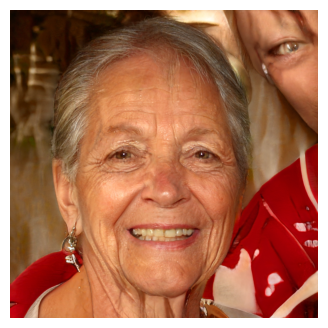

Step 0050 | Loss = 1.3027


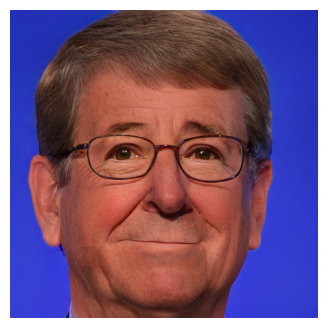

Step 0100 | Loss = 1.2012


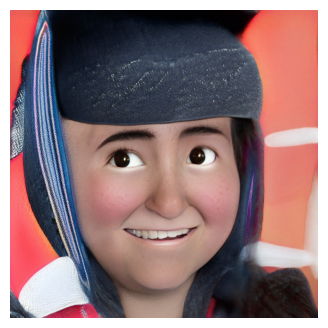

Step 0150 | Loss = 1.1641


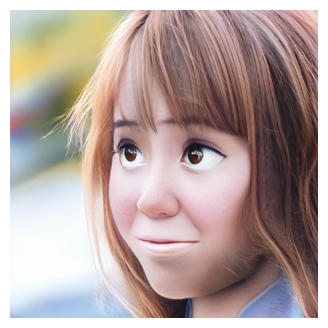

Step 0200 | Loss = 1.1543


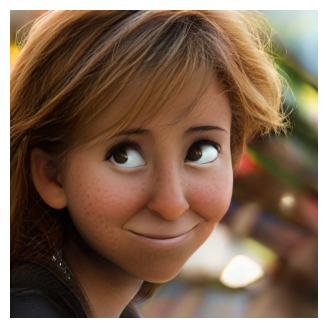

In [10]:
# TRAIN
target_G.train()

for step in range(num_steps):

    z = torch.randn(batch_size, latent_dim, device=device)

    # Frozen generator
    with torch.no_grad():
        w_src = source_G.style([z])
        src_img, _ = source_G(w_src, input_is_latent=True,)

    # Trainable generator
    w_tgt = target_G.style([z])
    tgt_img, _ = target_G(w_tgt, input_is_latent=True,)


    loss = 0
    for weight, loss_fn in zip(clip_weights, clip_losses):
        loss += weight * loss_fn(src_img, SOURCE, tgt_img, TARGET,)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Visualization
    if step % 50 == 0:
        print( f"Step {step:04d} | Loss = {loss.item():.4f}")
        img = (tgt_img[0].detach().cpu().permute(1,2,0).clamp(-1,1) + 1) / 2

        plt.figure(figsize=(4,4))
        plt.imshow(img)
        plt.axis("off")
        plt.show()

# Save weights

In [11]:
save_path = "/kaggle/working/disney_stylegan_nada.pt"
torch.save(
    {"g_ema": target_G.generator.state_dict()},
    save_path,
)
print("Saved:", save_path)

Saved: /kaggle/working/disney_stylegan_nada.pt
